<a href="https://colab.research.google.com/github/CaioAntonine/CaioAntonine_MVP_CEP/blob/main/Trabalho_Cep_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Avaliação Preditiva e Controle Estatístico na Produção de Cafés Especiais

**Descrição do Problema:** Avaliar a qualidade de lotes de café verde e torrado, unindo a inspeção de defeitos físicos com a predição da nota sensorial final (Total.Cup.Points).

**Conceito de Qualidade Para o Trabalho:** A qualidade do café especial é definida pela SCA (Specialty Coffee Association) por meio de avaliação sensorial com pontuação mínima de 80 pontos, considerando atributos como aroma, sabor, acidez, corpo, doçura e uniformidade. Lotes que não atingem esse padrão, por excesso de defeitos, falta de consistência sensorial ou baixa pontuação, são classificados como commodity.

*  A SCA (Specialty Coffee Association) "*é a maior associação mundial do setor de café especial. Ela define padrões de qualidade, promove pesquisa, educação e eventos, e conecta todos os elos da cadeia produtiva , de produtores a consumidores, com o objetivo de tornar o café especial um mercado mais próspero, justo e sustentável globalmente.*"

## Descrição do Dataset e Dicionário de Dados

Os dados utilizados neste projeto são provenientes do Coffee Quality Institute (CQI) - uma organização sem fins lucrativos que atua internacionalmente para melhorar a qualidade do café e a vida das pessoas que o produzem,foram extraídos e consolidados em repositórios públicos (Kaggle), contendo avaliações laboratoriais e sensoriais de lotes de cafés das espécies Arábica e Robusta (merged_data_cleaned.csv).

A base é composta por múltiplas observações (lotes de café) e suas respectivas features, que foram divididas nas seguintes categorias para a nossa análise:
### I. Variável Resposta (Target)

Total.Cup.Points: A nota global do café (escala contínua de 0 a 100), atribuída por avaliadores certificados (Q-Graders). Esta será a variável alvo do nosso modelo preditivo de Machine Learning.
### II. Variáveis de Identificação e Categoriais

Informações de rastreabilidade do processo que servirão para agrupar os dados (subgrupos racionais) ou como features categóricas na modelagem.
* Species: Espécie do grão (Arábica ou Robusta).
* Country.of.Origin: País onde o café foi cultivado.
* Processing.Method: Método de processamento pós-colheita (ex: Washed, Natural), que representa o "método de manufatura" do lote.
* Quakers:Grãos de café defeituosos que não torram adequadamente.
* Variety: Variedado do Grão
* Color: Coloração do Grão
### III. Variáveis Quantitativas

Características físicas e ambientais numéricas. Serão fundamentais para a criação das Cartas de Controle para Variáveis (Gráficos de Média e Amplitude).

*    Moisture: Nível percentual de umidade do grão verde. Uma umidade fora das especificações (causa atribuível) indica falha no processo de secagem.
*   altitude_mean_meters: Altitude média da fazenda produtora.

### IV. Atributos de Conformidade

Inspeção visual que contabiliza o número de falhas encontradas em uma amostra fixa (unidade de inspeção de tamanho constante, geralmente 350g). Serão utilizadas para a criação das Cartas de Controle para Atributos (Gráfico c).

 *   Category.One.Defects: Contagem de defeitos primários ou graves (ex: grão preto, grão azedo). Um único defeito desta categoria pode comprometer todo o lote.
 *   Category.Two.Defects: Contagem de defeitos secundários ou leves (ex: grão quebrado, dano por inseto).

### V. Características Sensoriais da Qualidade dadas aos atributos do café.

*    Aroma: A intensidade e a qualidade do cheiro
*    Sabor: gosto sentido no momento em que a bebida está na boca.
*    Finalização: Sabor que fica após o café ser engolido
*    Acidez: Frequentemente descrita como o "brilho" da bebida. Quando positiva e bem integrada, traz vivacidade, doçura e frescor (como a acidez de frutas cítricas maduras). Quando negativa, indica um processo falho, resultando em um café azedo, adstringente ou cáustico.
*    Corpo: A sensação tátil e física do líquido na boca. Avalia o "peso", a viscosidade ou a textura da bebida
*    Equilíbrio: A avaliação holística de como todos os atributos (Sabor, Finalização, Acidez e Corpo) interagem e trabalham em harmonia. Um café perde pontos em equilíbrio se um desses elementos se sobrepõe agressivamente aos demais.
*    Uniformidade: Mede a consistência do sabor com várias xícaras do mesmo lote.
*    Clean.Cup (Xícara Limpa): Avalia a transparência da bebida e a total ausência de impressões negativas do início ao fim da degustação.
*    Doçura: Uma percepção áçucar no sabor associada à maturação correta do grão.



## 1. Preparação e Tratamento de Dados

A qualidade do modelo e das cartas de controle depende da integridade dos dados. Como você mencionou, evitar o data leakage (vazamento de dados) é crucial.

* Criação do Target: Como o problema é de classificação, precisamos transformar a nota contínua (Total.Cup.Points) em categorias. Criaremos a variável Is_Specialty, onde notas >= 80 recebem 1 (Especial) e notas < 80 recebem 0 (Commodity).

* Limpeza de Outliers: Usaremos filtros lógicos no Pandas para remover altitudes impossíveis (ex: df = df[(df['altitude_mean_meters'] > 0) & (df['altitude_mean_meters'] < 4000)]). Isso evita que o modelo aprenda com ruídos.

* Engenharia de Atributos: A soma Total_Defects = Category.One.Defects + Category.Two.Defects consolida a contagem de falhas, facilitando a aplicação futura na carta de controle.

* Divisão dos Dados (Split): Utilizaremos a função train_test_split do Scikit-Learn. Separar os dados antes de qualquer preenchimento de nulos garante que o modelo seja treinado em um cenário realista, sem "espiar" informações do conjunto de teste.

* Imputação e Encodificação: Valores nulos em colunas como Moisture serão preenchidos com a mediana do conjunto de treino (usando SimpleImputer). Variáveis categóricas, como Processing.Method, serão transformadas em colunas binárias (0 ou 1) usando pd.get_dummies() ou OneHotEncoder, pois algoritmos matemáticos não interpretam texto.

In [51]:
# Bibliotecas Necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold



In [52]:
# Carregamos a base histórica do Coffee Quality Institute (CQI) diretamente do repositório.
# Esta base consolida as avaliações físicas e sensoriais (feitas por Q-Graders) que embasam nosso projeto.
df = pd.read_csv('https://raw.githubusercontent.com/CaioAntonine/CaioAntonine_MVP_CEP/refs/heads/main/merged_data_cleaned.csv')

# O algoritmo precisa de um alvo claro. Aqui, aplicamos a métrica oficial da SCA (Specialty Coffee Association).
# Criamos uma variável binária (0 ou 1) que será o "gabarito" do nosso modelo de classificação:
# 1 = Café Especial (Nota >= 80 pontos)
# 0 = Café Commodity (Nota < 80 pontos)
df['Is_Specialty'] = (df['Total.Cup.Points'] >= 80).astype(int)

# Criamos a variável 'Total_Defects' somando os defeitos primários e secundários.
# Motivação dupla:
# 1. Ajuda o modelo de Machine Learning a entender o peso total das falhas físicas.
df['Total_Defects'] = df['Category.One.Defects'] + df['Category.Two.Defects']

# Analisamos o tamanho do dataset e a proporção entre cafés Especiais e Commodities.
print(f"Total de registros originais: {df.shape[0]}")
print(f"Distribuição da Qualidade:\n{df['Is_Specialty'].value_counts(normalize=True) * 100}")

Total de registros originais: 1339
Distribuição da Qualidade:
Is_Specialty
1    86.034354
0    13.965646
Name: proportion, dtype: float64


In [53]:
#Limpeza de Outliers Absurdos
# Filtro lógico: A altitude média do café raramente passa de 2500m-3000m.
mask_altitude = (
    (df['altitude_mean_meters'] > 0) &
    (df['altitude_mean_meters'] <= 4000) |
    (df['altitude_mean_meters'].isnull())
)

df_clean = df[mask_altitude].copy()

print(f"Registros após limpeza de outliers de altitude: {df_clean.shape[0]}")

Registros após limpeza de outliers de altitude: 1333


In [54]:
##Definir as variáveis preditoras e segregar os dados de forma segura.


features_reais = [
    'Species',              # Categoria: Espécie (Arábica/Robusta)
    'Color',                # Categoria: Frescor / Qualidade de Secagem
    'Processing.Method',    # Categoria: Método de processamento
    'Moisture',             # Variável Contínua: Nível de umidade
    'altitude_mean_meters', # Variável Contínua: Condição de cultivo
    'Total_Defects',        # Atributo de Contagem: Defeitos físicos
    'Quakers'               # Atributo de Contagem: Grãos defeituosos na torra
]

# Separamos a matriz de atributos (X) e o vetor alvo (y)
X = df_clean[features_reais]
y = df_clean['Is_Specialty']

# O parâmetro 'stratify=y' garante a mesma proporção de classes nas divisões
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Criando a estrutura 70-15-15 (Treino, Validação, Teste)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Tamanho do Treino: {X_train.shape[0]} (70%)")
print(f"Tamanho da Validação: {X_val.shape[0]} (15%)")
print(f"Tamanho do Teste: {X_test.shape[0]} (15%)")

Tamanho do Treino: 933 (70%)
Tamanho da Validação: 200 (15%)
Tamanho do Teste: 200 (15%)


In [55]:
## Tratar dados faltantes, agrupar categorias raras e balancear classes.

# [NOVO AJUSTE: MAPEAMENTO DAS NOVAS COLUNAS]
num_cols = ['Moisture', 'altitude_mean_meters', 'Total_Defects', 'Quakers']
cat_cols = ['Species', 'Processing.Method','Color']

num_transformer = SimpleImputer(strategy='median')

# Adicionamos min_frequency=0.03. Isso evita a explosão de colunas.
# Categorias com menos de 3% de frequência viram um grupo único.
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, min_frequency=0.03))
])

# Unimos os transformadores
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# Aplicamos fit_transform() apenas no treino (Prevenção de Data Leakage)
X_train_processed = preprocessor.fit_transform(X_train)

# Nos dados de validação e teste, usamos APENAS transform()
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Recuperamos os nomes das colunas (as categorias raras agora aparecerão como 'infrequent')
cat_features_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(cat_cols)
all_feature_names = num_cols + list(cat_features_names)

X_train_final = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_val_final = pd.DataFrame(X_val_processed, columns=all_feature_names, index=X_val.index)
X_test_final = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print("\n--- Antes do SMOTE ---")
print(y_train.value_counts(normalize=True) * 100)

# Instanciamos e aplicamos o SMOTE apenas no Treino
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print("\n--- Depois do SMOTE ---")
print(y_train_balanced.value_counts(normalize=True) * 100)
print(f"Novo tamanho da base de treino: {X_train_balanced.shape[0]} linhas")
print("Processamento de dados concluído com sucesso!")
print(f"Quantidade final de features otimizada: {X_train_final.shape[1]}")


--- Antes do SMOTE ---
Is_Specialty
1    86.066452
0    13.933548
Name: proportion, dtype: float64

--- Depois do SMOTE ---
Is_Specialty
0    50.0
1    50.0
Name: proportion, dtype: float64
Novo tamanho da base de treino: 1606 linhas
Processamento de dados concluído com sucesso!
Quantidade final de features otimizada: 13


## 2. Competição Entre Modelos de Machine Learning

Para encontrar o algoritmo mais adequado, colocaremos diferentes modelos para competir, avaliando métricas como Acurácia, Precisão e Recall (capacidade de identificar corretamente os cafés especiais).

* Regressão Logística: Servirá como nosso modelo base (baseline). É simples, rápido e excelente para entender relações lineares, mas pode não capturar interações complexas entre os atributos sensoriais.

* Random Forest: É um conjunto de árvores de decisão. É altamente robusto contra outliers e lida muito bem com dados não lineares, o que é útil já que a pontuação de atributos sensoriais pode ter impactos variados.

* XGBoost: Um modelo baseado em Gradient Boosting que corrige iterativamente os erros das árvores anteriores. Costuma entregar a melhor performance preditiva e lida nativamente com dados complexos.

A utilidade de rodar uma competição é garantir que não estamos escolhendo um algoritmo às cegas. O modelo vencedor será aquele que melhor equilibrar a precisão das previsões com a capacidade de generalização para dados novos.

**A Escolha do Baseline:** A Regressão Logística é o nosso "feijão com arroz". Ela pressupõe que a relação entre as notas sensoriais e ser um "Café Especial" é uma linha reta. Se o Random Forest ou o XGBoost (que são modelos mais complexos e não-lineares) não conseguirem bater a Regressão Logística, significa que a relação dos dados é simples e não precisamos de um modelo complexo.

**ROC-AUC como Métrica Principal:** O ROC-AUC Médio nos diz a probabilidade do modelo ranquear um café especial aleatório acima de um café commodity aleatório. É a métrica mais robusta para classificar a qualidade de um modelo, não importa o quão desbalanceados sejam os dados.

**Desvio Padrão do ROC-AUC:** Adicionei essa coluna no resultado porque consistência é crucial. Se um modelo tem um ROC-AUC de 90%, mas um desvio padrão de 15%, ele é instável. Um modelo de 85% com desvio de 1% é muito mais confiável para ir para a produção agrícola.

Iniciando a busca de hiperparâmetros...

Otimizando: Regressão Logística (SMOTE)...
Otimizando: XGBoost (SMOTE)...
Otimizando: Balanced Random Forest (Nativo)...


,Modelo,ROC-AUC,Melhores Parâmetros
2,Balanced Random Forest (Nativo),0.747383,"{'n_estimators': 500, 'max_depth': 7}"
1,XGBoost (SMOTE),0.708706,"{'classificador__n_estimators': 300, 'classifi..."
0,Regressão Logística (SMOTE),0.678925,"{'classificador__max_iter': 2000, 'classificad..."



Modelo Vencedor Geral: Balanced Random Forest (Nativo)

O Limiar de Decisão Ótimo (Matematicamente Calculado) é: 38.7%

=== Relatório de Classificação ===
              precision    recall  f1-score   support

   Commodity       0.56      0.50      0.53        28
    Especial       0.92      0.94      0.93       172

    accuracy                           0.88       200
   macro avg       0.74      0.72      0.73       200
weighted avg       0.87      0.88      0.87       200

ROC-AUC na Validação: 0.7856


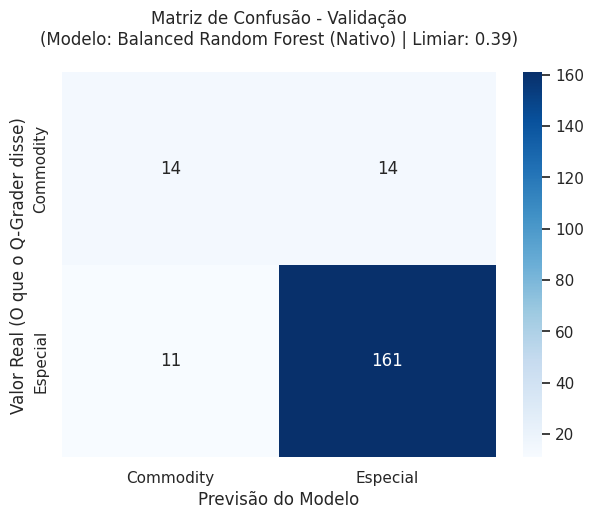

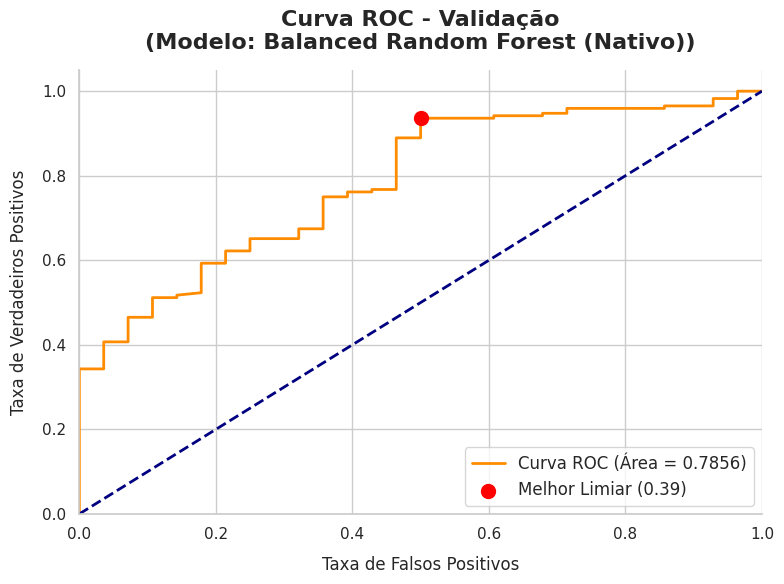

In [56]:
modelos = {
    "Regressão Logística (SMOTE)": ImbPipeline([
        ('smote', SMOTE(random_state=7)),
        ('classificador', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),

    "XGBoost (SMOTE)": ImbPipeline([
        ('smote', SMOTE(random_state=7)),
        ('classificador', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
    ]),

    "Balanced Random Forest (Nativo)": BalancedRandomForestClassifier(
        n_estimators=500, max_depth=7, sampling_strategy='all', replacement=True, random_state=42
    )
}

warnings.filterwarnings('ignore')

modelos = {
    "Regressão Logística (SMOTE)": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classificador', LogisticRegression(class_weight='balanced', random_state=42))
    ]),

    "XGBoost (SMOTE)": ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('classificador', XGBClassifier(eval_metric='logloss', random_state=42))
    ]),

    "Balanced Random Forest (Nativo)": BalancedRandomForestClassifier(
        sampling_strategy='all', replacement=True, random_state=42
    )
}

grades_parametros = {
    "Regressão Logística (SMOTE)": {
        'classificador__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classificador__max_iter': [500, 1000, 2000]
    },
    "XGBoost (SMOTE)": {
        'classificador__n_estimators': [100, 200, 300],
        'classificador__learning_rate': [0.01, 0.1, 0.2],
        'classificador__max_depth': [3, 5, 7]
    },
    "Balanced Random Forest (Nativo)": {
        'n_estimators': [100, 300, 500],
        'max_depth': [5, 7, 10, None]
    }
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_competicao = []
modelos_otimizados = {}

print("Iniciando a busca de hiperparâmetros...\n")

for nome, algoritmo in modelos.items():
    print(f"Otimizando: {nome}...")

    busca = RandomizedSearchCV(
        estimator=algoritmo,
        param_distributions=grades_parametros[nome],
        n_iter=10,
        scoring='roc_auc',
        cv=skf,
        random_state=42,
        n_jobs=-1
    )

    busca.fit(X_train_final, y_train)
    modelos_otimizados[nome] = busca.best_estimator_

    resultados_competicao.append({
        'Modelo': nome,
        'ROC-AUC': busca.best_score_,
        'Melhores Parâmetros': str(busca.best_params_)
    })

df_resultados = pd.DataFrame(resultados_competicao).sort_values(by='ROC-AUC', ascending=False)
display(df_resultados)

nome_vencedor = df_resultados.iloc[0]['Modelo']

modelo_vencedor = modelos_otimizados[nome_vencedor]

print(f"\nModelo Vencedor Geral: {nome_vencedor}")

# Coletamos as probabilidades na base de validação
y_proba_val = modelo_vencedor.predict_proba(X_val_final)[:, 1]

# Calcula as taxas de falsos positivos (fpr), verdadeiros positivos (tpr) e todos os limiares testados
fpr, tpr, thresholds = roc_curve(y_val, y_proba_val)

# Calcula o Índice J para cada limiar (TPR - FPR)
j_scores = tpr - fpr

# Encontra a posição (índice) do maior valor de J
best_idx = np.argmax(j_scores)

# Resgata qual foi o limiar exato que gerou esse melhor resultado
limiar_otimo = thresholds[best_idx]

print(f"\nO Limiar de Decisão Ótimo (Matematicamente Calculado) é: {limiar_otimo*100:.1f}%")

# Aplicamos o limiar ótimo recém-descoberto
y_pred_final = (y_proba_val >= limiar_otimo).astype(int)

print("\n=== Relatório de Classificação ===")
print(classification_report(y_val, y_pred_final, target_names=['Commodity', 'Especial']))

# Corrigido o erro de digitação (y_aproba_val -> y_proba_val)
auc_score = roc_auc_score(y_val, y_proba_val)
print(f"ROC-AUC na Validação: {auc_score:.4f}")

# --- Matriz de Confusão ---
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_val, y_pred_final)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Commodity', 'Especial'],
            yticklabels=['Commodity', 'Especial'])

plt.title(f'Matriz de Confusão - Validação\n(Modelo: {nome_vencedor} | Limiar: {limiar_otimo:.2f})', pad=20)
plt.ylabel('Valor Real (O que o Q-Grader disse)')
plt.xlabel('Previsão do Modelo')
plt.show()

# --- Curva ROC ---
plt.figure(figsize=(8, 6))

# Plota a curva do modelo
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (Área = {auc_score:.4f})')

# Destaca o ponto ótimo descoberto no gráfico
plt.scatter(fpr[best_idx], tpr[best_idx], marker='o', color='red', s=100, zorder=5,
            label=f'Melhor Limiar ({limiar_otimo:.2f})')

# Plota a linha de base (chute aleatório de 50%)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Estilização
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos', fontsize=12, labelpad=10)
plt.ylabel('Taxa de Verdadeiros Positivos', fontsize=12, labelpad=10)
plt.title(f'Curva ROC - Validação\n(Modelo: {nome_vencedor})', fontsize=16, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=12)

# Deixa o gráfico mais limpo
sns.despine()
plt.tight_layout()
plt.show()

A avaliação dos modelos foi pautada na métrica ROC-AUC (Área Sob a Curva ROC), considerada a mais robusta para lidar com o forte desbalanceamento natural da nossa base de dados (onde cafés Especiais são a esmagadora maioria).

O algoritmo Balanced Random Forest (Nativo) consolidou-se como o vencedor, atingindo um ROC-AUC de 0.7856 na base de validação. Diferente dos modelos baseados em regressão ou boosting que utilizaram SMOTE (geração de dados sintéticos), o Balanced Random Forest utiliza uma técnica de subamostragem dinâmica nativa, aprendendo as fronteiras de decisão exclusivamente com dados reais.

## 3. Sensibilidade e Impacto (Feature Importance)

Após escolher o melhor modelo, precisamos entender o que mais afeta a pontuação do café.

* Utilidade Prática: Isso nos dirá, por exemplo, qual variável tem peso maior na classificação de um café como especial

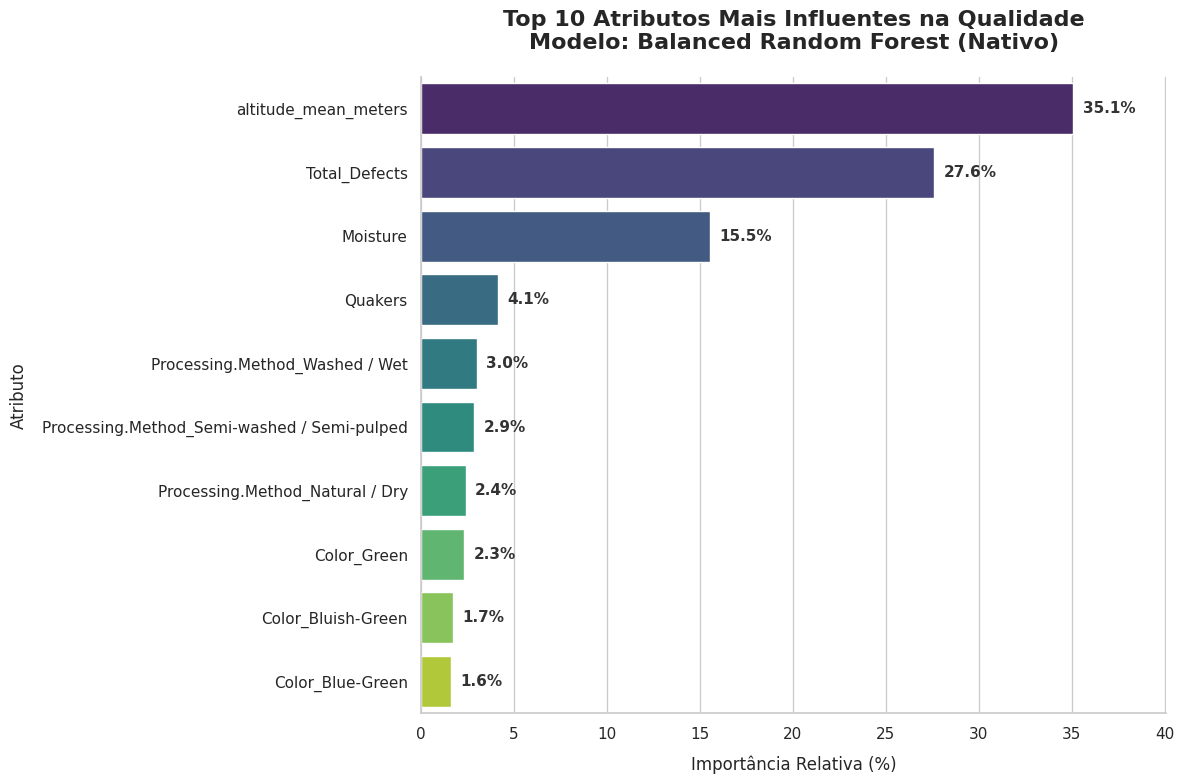

Os atributos no topo do gráfico são os que possuem o maior peso percentual na decisão do modelo entre classificar um café como Especial ou Commodity.


In [57]:
if isinstance(modelo_vencedor, (Pipeline, ImbPipeline)):
    classificador_final = modelo_vencedor.named_steps['classificador']
else:
    classificador_final = modelo_vencedor

if hasattr(classificador_final, 'feature_importances_'):
    importancias = classificador_final.feature_importances_
elif hasattr(classificador_final, 'coef_'):
    importancias = np.abs(classificador_final.coef_[0])
else:
    importancias = np.zeros(len(all_feature_names))
    print("Aviso: O modelo vencedor não suporta extração direta de importância de atributos.")

# Somamos o total de importância e dividimos cada item pelo total, multiplicando por 100
total_importancia = importancias.sum()
percentuais = (importancias / total_importancia) * 100 if total_importancia > 0 else importancias

df_importancia = pd.DataFrame({
    'Atributo': all_feature_names,
    'Importancia_Absoluta': importancias,
    'Percentual': percentuais
}).sort_values(by='Percentual', ascending=False)

# Pegamos os top 10 para o gráfico
top_10 = df_importancia.head(10)

# Limpamos o fundo e removemos as bordas superior e direita para um visual mais "clean"
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})

plt.figure(figsize=(12, 8))

# Plotamos usando a coluna 'Percentual' no eixo X. A paleta 'viridis' oferece ótimo contraste.
ax = sns.barplot(
    data=top_10,
    x='Percentual',
    y='Atributo',
    hue='Atributo',
    palette='viridis',
    legend=False
)

# O loop abaixo passa por cada barra desenhada (patch) e escreve o valor exato no final dela
for p in ax.patches:
    largura = p.get_width()
    plt.text(
        largura + 0.5,                   # Posição X (um pouco à direita do fim da barra)
        p.get_y() + p.get_height() / 2,  # Posição Y (exatamente no centro vertical da barra)
        f'{largura:.1f}%',               # Texto formatado com 1 casa decimal
        ha='left',                       # Alinhamento horizontal à esquerda
        va='center',                     # Alinhamento vertical centralizado
        fontsize=11,
        fontweight='bold',
        color='#333333'                  # Cor do texto (cinza escuro)
    )

plt.title(f'Top 10 Atributos Mais Influentes na Qualidade\nModelo: {nome_vencedor}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Importância Relativa (%)', fontsize=12, labelpad=10)
plt.ylabel('Atributo', fontsize=12, labelpad=10)

# Damos um pequeno respiro no eixo X para garantir que o texto do rótulo não seja cortado
plt.xlim(0, top_10['Percentual'].max() + 5)

plt.tight_layout()
plt.show()

# Conclusão gerencial
print("Os atributos no topo do gráfico são os que possuem o maior peso percentual na decisão do modelo entre classificar um café como Especial ou Commodity.")

## 4. Controle Estatístico de Processo (CEP)

O CEP entra como a ferramenta de diagnóstico contínuo. Enquanto o Machine Learning prevê o resultado final, o CEP garante que o processo de fabricação (ou beneficiamento do café) se mantenha estável e previsível, reduzindo a variabilidade.

Gráficos para Variáveis ($\bar{X}$ e R)Características medidas em escala numérica contínua, como a umidade (Moisture), exigem gráficos de média e amplitude.

* Como fazer: Agruparemos os dados por fazenda (subgrupos racionais).O Gráfico $\bar{X}$ monitorará a média da umidade dos lotes, garantindo que o processo de secagem esteja centrado no alvo. O Gráfico R monitorará a variação (amplitude) dessa umidade dentro dos subgrupos.

* Utilidade: Identificar imediatamente se uma máquina de secagem desregulou (causa atribuível), permitindo correção antes que o café estrague.

Gráfico para Atributos (Gráfico c)Para características que envolvem a contagem de falhas em uma unidade de inspeção constante (como a amostra fixa de 350g do protocolo SCA), utilizamos o Gráfico c.  

* Como fazer: Usaremos a variável Total_Defects. Calcularemos o limite central ($LM = c$), o limite superior de controle ($LSC = c + 3\sqrt{c}$) e o limite inferior ($LIC = c - 3\sqrt{c}$).  
* Utilidade: Se um lote ultrapassar o limite superior de defeitos, a equipe de qualidade saberá matematicamente que ocorreu uma anomalia grave no processamento (ex: infestação de pragas ou quebra no moinho), justificando uma investigação imediata.

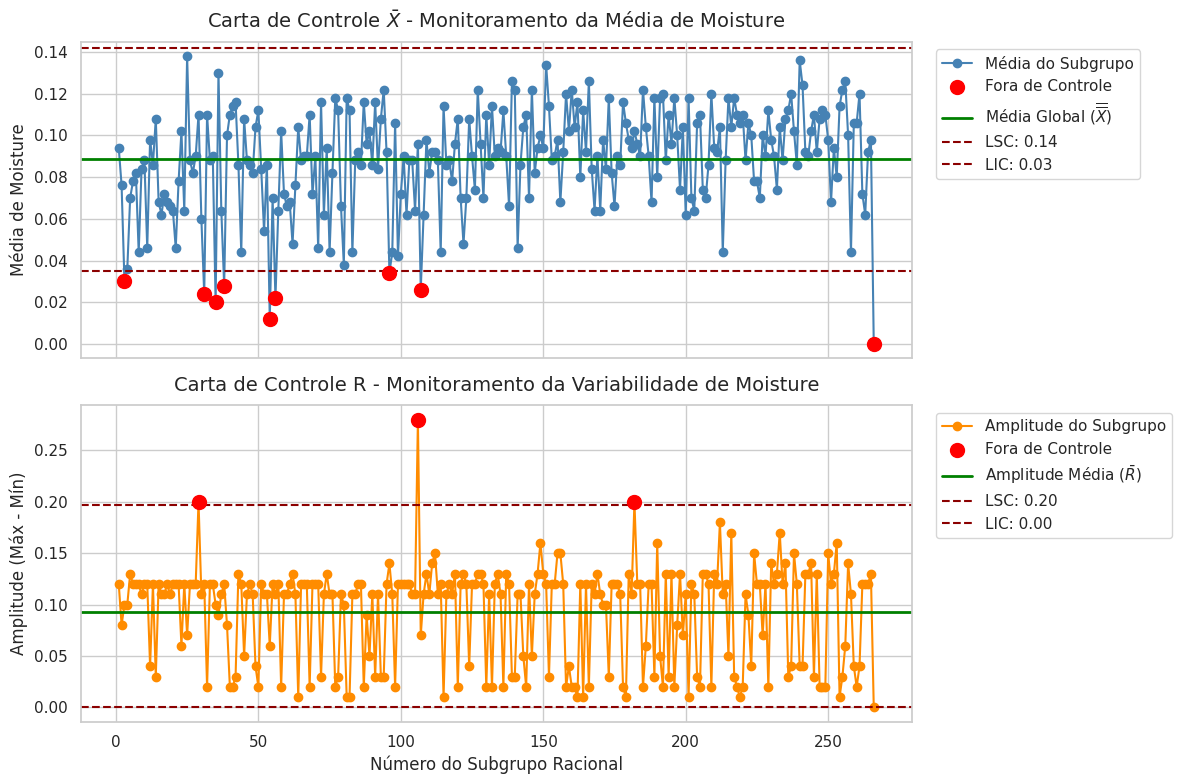

 RELATÓRIO DO CONTROLE ESTATÍSTICO DE PROCESSO: MOISTURE
 Total de Subgrupos    : 266 (n=5)
 Média Global (X-bar)  : 0.0885
 Amplitude Média (R-bar): 0.0929
------------------------------------------------------------
 Carta da Média (X-bar) -> LIC: 0.0349 | LSC: 0.1421
 Carta Amplitude (R)    -> LIC: 0.0000 | LSC: 0.1966
 Anomalias (Média)     : 9 subgrupos fora de controle.
 Anomalias (Amplitude) : 3 subgrupos fora de controle.


In [58]:
def plot_carta_xbar_r(df, variavel, tamanho_subgrupo=5):

    # 1. Preparação dos Subgrupos Racionais
    # Limpeza de nulos e extração do array de dados contínuos
    dados = df[variavel].dropna().values
    n_subgrupos = len(dados) // tamanho_subgrupo

    # Truncando os dados para formar matrizes completas e remodelando
    dados_matriz = dados[:n_subgrupos * tamanho_subgrupo].reshape(n_subgrupos, tamanho_subgrupo)

    # Cálculo da Média (X-bar) e Amplitude (R - Peak to Peak) para cada subgrupo
    x_bar = np.mean(dados_matriz, axis=1)
    r = np.ptp(dados_matriz, axis=1)

    # 2. Cálculo dos Parâmetros e Limites de Controle
    # Constantes estatísticas de Shewhart para n=5
    A2, D3, D4 = 0.577, 0, 2.115

    # Linhas Centrais (Médias Globais)
    x_double_bar = np.mean(x_bar)
    r_bar = np.mean(r)

    # Limites da Carta X-bar (Média)
    lsc_x = x_double_bar + A2 * r_bar
    lic_x = x_double_bar - A2 * r_bar

    # Limites da Carta R (Amplitude)
    lsc_r = D4 * r_bar
    lic_r = D3 * r_bar

    # Identificação Lógica de Causas Especiais (Pontos fora dos limites)
    out_x = (x_bar > lsc_x) | (x_bar < lic_x)
    out_r = (r > lsc_r) | (r < lic_r)

    amostras = np.arange(1, n_subgrupos + 1)

    # 3. Plotagem dos Gráficos
    sns.set_theme(style="whitegrid")
    # sharex=True garante que o eixo X de ambos os gráficos seja sincronizado
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

    # --- Gráfico 1: Carta X-bar (Média) ---
    ax1.plot(amostras, x_bar, marker='o', color='steelblue', linestyle='-', linewidth=1.5, label='Média do Subgrupo')
    # Destacando pontos anômalos
    ax1.scatter(amostras[out_x], x_bar[out_x], color='red', s=100, zorder=5, label='Fora de Controle')

    ax1.axhline(x_double_bar, color='green', linestyle='-', linewidth=2, label=rf'Média Global ($\overline{{\overline{{X}}}}$)')
    ax1.axhline(lsc_x, color='darkred', linestyle='--', label=f'LSC: {lsc_x:.2f}')
    ax1.axhline(lic_x, color='darkred', linestyle='--', label=f'LIC: {lic_x:.2f}')

    ax1.set_title(rf'Carta de Controle $\bar{{X}}$ - Monitoramento da Média de {variavel}', fontsize=14, pad=10)
    ax1.set_ylabel(f'Média de {variavel}', fontsize=12)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1)) # Legenda fora da área de plotagem

    # --- Gráfico 2: Carta R (Amplitude) ---
    ax2.plot(amostras, r, marker='o', color='darkorange', linestyle='-', linewidth=1.5, label='Amplitude do Subgrupo')
    # Destacando pontos anômalos
    ax2.scatter(amostras[out_r], r[out_r], color='red', s=100, zorder=5, label='Fora de Controle')

    ax2.axhline(r_bar, color='green', linestyle='-', linewidth=2, label=rf'Amplitude Média ($\bar{{R}}$)')
    ax2.axhline(lsc_r, color='darkred', linestyle='--', label=f'LSC: {lsc_r:.2f}')
    ax2.axhline(lic_r, color='darkred', linestyle='--', label=f'LIC: {lic_r:.2f}')

    ax2.set_title(f'Carta de Controle R - Monitoramento da Variabilidade de {variavel}', fontsize=14, pad=10)
    ax2.set_xlabel('Número do Subgrupo Racional', fontsize=12)
    ax2.set_ylabel('Amplitude (Máx - Mín)', fontsize=12)
    ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1)) # Legenda fora da área de plotagem

    plt.tight_layout()
    plt.show()

    # 4. Relatório Estatístico
    print("=" * 60)
    print(f" RELATÓRIO DO CONTROLE ESTATÍSTICO DE PROCESSO: {variavel.upper()}")
    print("=" * 60)
    print(f" Total de Subgrupos    : {n_subgrupos} (n={tamanho_subgrupo})")
    print(f" Média Global (X-bar)  : {x_double_bar:.4f}")
    print(f" Amplitude Média (R-bar): {r_bar:.4f}")
    print("-" * 60)
    print(f" Carta da Média (X-bar) -> LIC: {lic_x:.4f} | LSC: {lsc_x:.4f}")
    print(f" Carta Amplitude (R)    -> LIC: {lic_r:.4f} | LSC: {lsc_r:.4f}")
    print(f" Anomalias (Média)     : {sum(out_x)} subgrupos fora de controle.")
    print(f" Anomalias (Amplitude) : {sum(out_r)} subgrupos fora de controle.")
    print("=" * 60)
plot_carta_xbar_r(df_clean, variavel='Moisture', tamanho_subgrupo=5)

Nesta etapa, o projeto assume a perspectiva de uma Cafeteria Global(Starbucks ou Nespresso). Por recebermos lotes do mundo inteiro, a nossa base de dados mistura diferentes origens, terroirs e métodos de secagem. Consequentemente, os limites da carta não refletem o padrão de uma única fazenda, mas sim a janela de aceitação global da nossa cadeia de suprimentos.

### **Diagnóstico da Carta de Média ($\bar{X}$):**
* Média Global: 8.85% (0.0885). Nosso fluxo de recebimento opera abaixo da umidade ideal de mercado (10% a 12%).
* Limites de Controle: A variação aceitável dos nossos fornecedores globais flutua entre 3.49% e 14.21%. A amplitude dessa banda reflete as diferenças climáticas naturais entre os países de origem.
* Anomalias (9 subgrupos): Representam lotes ou fornecedores específicos que romperam o nosso limite máximo ou mínimo de aceitação global, exigindo bloqueio ou renegociação comercial antes da torra.

### **Diagnóstico da Carta de Amplitude ($R$):**
* Anomalias (3 subgrupos): Indicam um alerta crítico de "desuniformidade". Nesses 3 casos específicos, os fornecedores entregaram sacas onde os grãos do mesmo lote apresentavam umidades drasticamente diferentes entre si (estouro do LSC de 19.66%), o que inviabiliza uma torra padronizada.


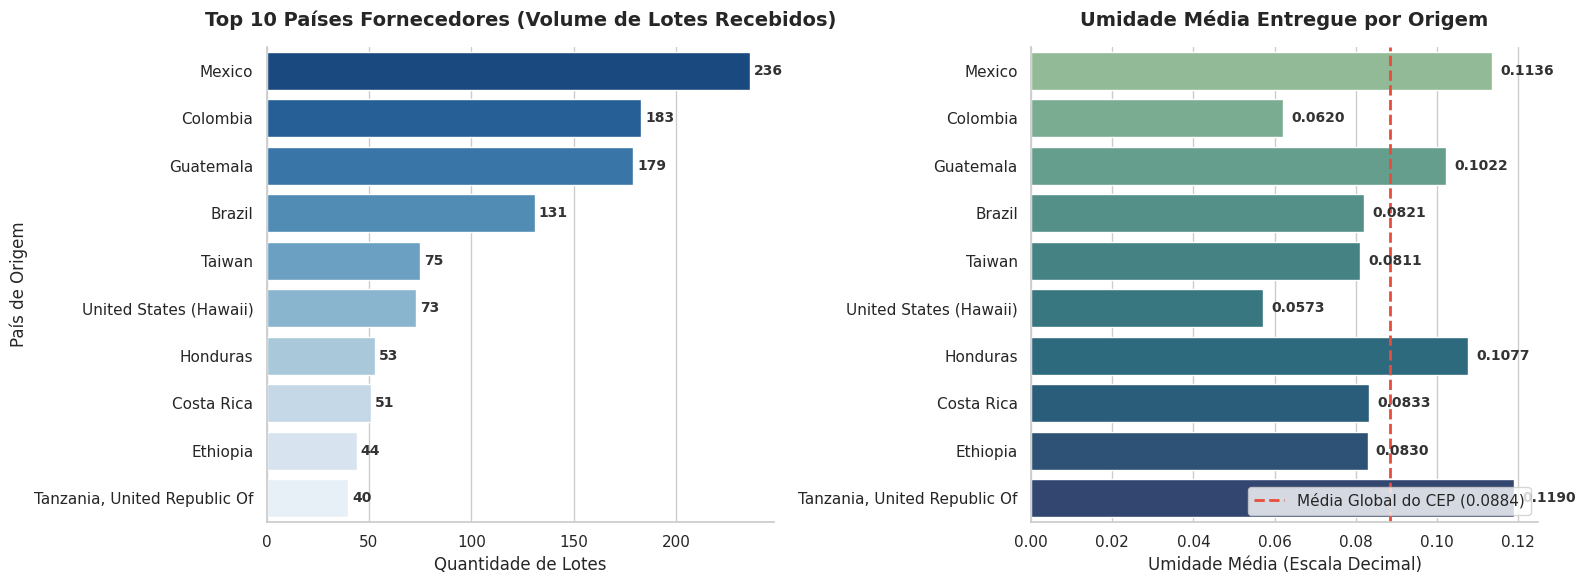

In [59]:
## Mapear o volume de lotes por país e a umidade média entregue por cada origem
df_pais = df_clean.groupby('Country.of.Origin').agg(
    Total_Lotes=('Country.of.Origin', 'count'),
    Umidade_Media=('Moisture', 'mean')
).reset_index()

df_pais_top10 = df_pais.sort_values(by='Total_Lotes', ascending=False).head(10)

media_global = df_clean['Moisture'].mean()

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICO 1: Distribuição de Lotes ---
sns.barplot(
    data=df_pais_top10,
    y='Country.of.Origin',
    x='Total_Lotes',
    hue='Country.of.Origin',
    legend=False,
    ax=axes[0],
    palette='Blues_r'
)
axes[0].set_title('Top 10 Países Fornecedores (Volume de Lotes Recebidos)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Quantidade de Lotes', fontsize=12)
axes[0].set_ylabel('País de Origem', fontsize=12)

for p in axes[0].patches:
    largura = p.get_width()
    axes[0].text(largura + 2, p.get_y() + p.get_height()/2, f'{int(largura)}',
                 ha='left', va='center', fontsize=10, fontweight='bold', color='#333333')

# --- GRÁFICO 2: Umidade Média ---
sns.barplot(
    data=df_pais_top10,
    y='Country.of.Origin',
    x='Umidade_Media',
    hue='Country.of.Origin',
    legend=False,
    ax=axes[1],
    palette='crest',
)
axes[1].set_title('Umidade Média Entregue por Origem', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Umidade Média (Escala Decimal)', fontsize=12)
axes[1].set_ylabel('')

axes[1].axvline(media_global, color='#e74c3c', linestyle='--', linewidth=2,
                label=f'Média Global do CEP ({media_global:.4f})')
axes[1].legend(loc='lower right', fontsize=11)

for p in axes[1].patches:
    largura = p.get_width()
    axes[1].text(largura + 0.002, p.get_y() + p.get_height()/2, f'{largura:.4f}',
                 ha='left', va='center', fontsize=10, fontweight='bold', color='#333333')

plt.tight_layout()
plt.show()

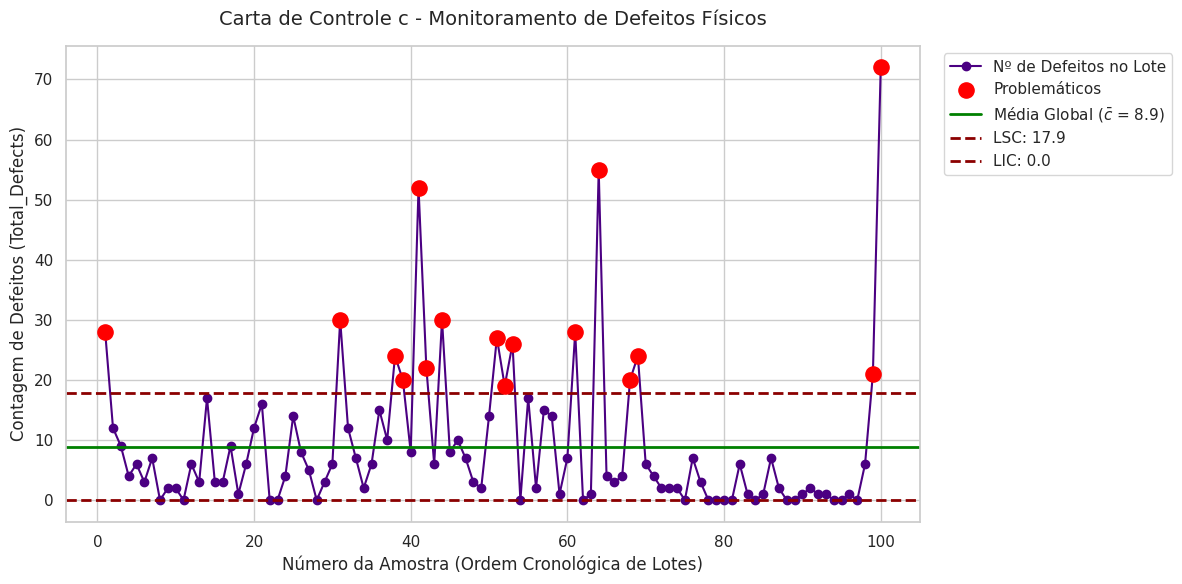

 RELATÓRIO DO CONTROLE ESTATÍSTICO DE ATRIBUTOS (Gráfico c)
 Variável Monitorada   : Total_Defects
 Total de Lotes Inspecionados.: 100
 Média de Defeitos (c) : 8.9200
------------------------------------------------------------
 Limite Inferior (LIC) : 0.0000
 Limite Superior (LSC) : 17.8799
 Anomalias Detectadas  : 16 lote(s) com causas atribuíveis.


In [60]:
def plot_carta_c(df, variavel_defeitos='Total_Defects', ultimos_n=5):

    # 1. Preparação dos Dados
    defeitos = df[variavel_defeitos].dropna().values

    # Se especificado, pegamos apenas os últimos N lotes da esteira de produção
    if ultimos_n is not None:
        defeitos = defeitos[-ultimos_n:]

    n_amostras = len(defeitos)
    amostras = np.arange(1, n_amostras + 1)

    # 2. Cálculos Estatísticos (Baseados na Distribuição de Poisson)
    # Linha Central (Média de defeitos por amostra)
    c_bar = np.mean(defeitos)

    # Desvio Padrão para Poisson é a raiz quadrada da média
    std_c = np.sqrt(c_bar)

    # Limites de Controle (3-sigmas)
    lsc_c = c_bar + 3 * std_c
    lic_c = c_bar - 3 * std_c

    # O limite inferior não pode ser menor que zero (não existe "defeito negativo")
    lic_c = max(0, lic_c)

    # Identificação Lógica de Causas Atribuíveis (Pontos fora de controle)
    out_c = (defeitos > lsc_c) | (defeitos < lic_c)

    # 3. Plotagem
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))

    # Linha principal de tendência dos defeitos
    plt.plot(amostras, defeitos, marker='o', color='indigo', linestyle='-', linewidth=1.5, label='Nº de Defeitos no Lote')

    # Destacando visualmente as anomalias
    if any(out_c):
        plt.scatter(amostras[out_c], defeitos[out_c], color='red', s=120, zorder=5, label='Problemáticos')

    # Adicionando as linhas estatísticas de controle
    plt.axhline(c_bar, color='green', linestyle='-', linewidth=2, label=rf'Média Global ($\bar{{c}}$ = {c_bar:.1f})')
    plt.axhline(lsc_c, color='darkred', linestyle='--', linewidth=2, label=f'LSC: {lsc_c:.1f}')
    plt.axhline(lic_c, color='darkred', linestyle='--', linewidth=2, label=f'LIC: {lic_c:.1f}')

    # Estilização
    plt.title(f'Carta de Controle c - Monitoramento de Defeitos Físicos', fontsize=14, pad=15)
    plt.xlabel('Número da Amostra (Ordem Cronológica de Lotes)', fontsize=12)
    plt.ylabel(f'Contagem de Defeitos ({variavel_defeitos})', fontsize=12)
    plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1)) # Legenda para o lado de fora

    plt.tight_layout()
    plt.show()

    # 4. Relatório Estatístico
    print("=" * 60)
    print(f" RELATÓRIO DO CONTROLE ESTATÍSTICO DE ATRIBUTOS (Gráfico c)")
    print("=" * 60)
    print(f" Variável Monitorada   : {variavel_defeitos}")
    print(f" Total de Lotes Inspecionados.: {n_amostras}")
    print(f" Média de Defeitos (c) : {c_bar:.4f}")
    print("-" * 60)
    print(f" Limite Inferior (LIC) : {lic_c:.4f}")
    print(f" Limite Superior (LSC) : {lsc_c:.4f}")
    print(f" Anomalias Detectadas  : {sum(out_c)} lote(s) com causas atribuíveis.")
    print("=" * 60)

plot_carta_c(df_clean, variavel_defeitos='Total_Defects', ultimos_n=100)

### **Diagnóstico da Carta de Atributos (c):**
*   **Média de Defeitos (c-bar):** 8.92 defeitos por lote (350g). Esta é a nossa referência para a qualidade esperada.
*   **Limites de Controle:** Flutuam entre 0 e 17.88 defeitos. Lotes que excedem esses limites não são considerados "normais" para o nosso processo.
*   **Anomalias (16 lotes):** Houve 16 lotes que "estouraram" os limites de controle, ou seja, apresentaram uma quantidade de defeitos significativamente alta (acima de 17.88). Esses lotes são indicativos de uma "causa atribuível" ou anomalia no processo. **Ação Imediata:** A equipe de qualidade deve investigar o porquê desses lotes apresentaram tantos defeitos. (Ex: Falha na máquina de beneficiamento, problema na colheita, infestação de pragas, etc.).

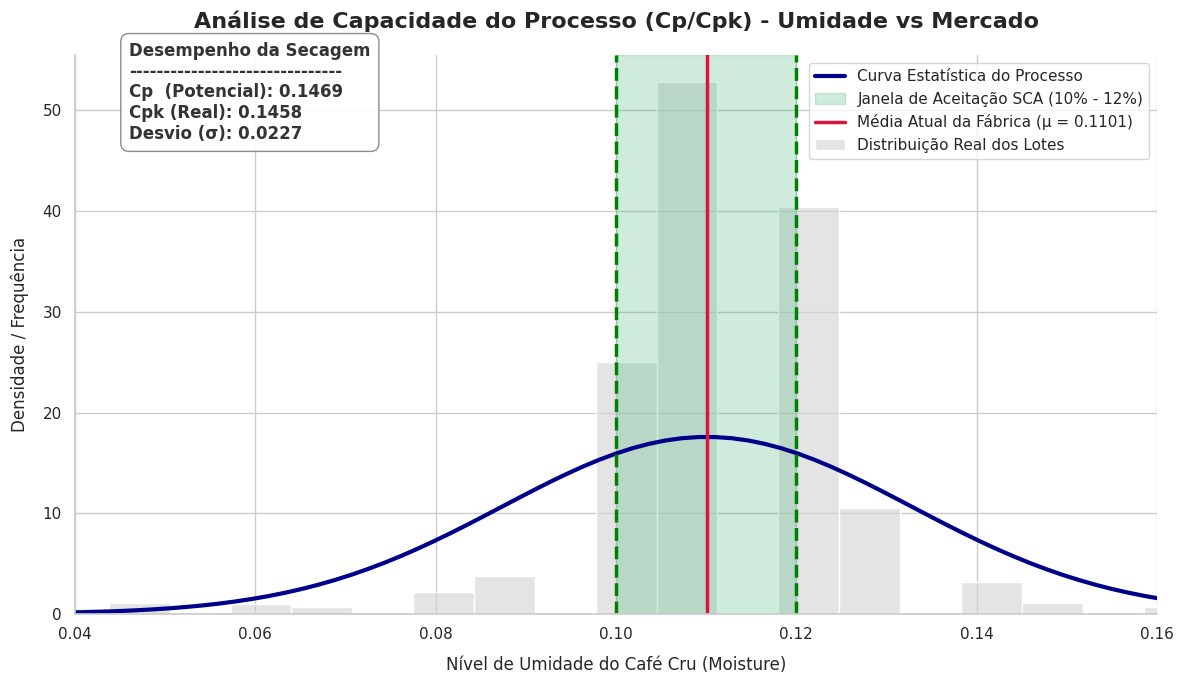

In [61]:
## Mostrar graficamente se a curva de (Moisture) dos fornecedores é aceita dentro da "janela" de aceitação do mercado (SCA).
from scipy.stats import norm

# Filtramos os dados removendo nulos e zeros irreais
umidade = df_clean[df_clean['Moisture'] > 0.0]['Moisture']

mu = umidade.mean()
sigma = umidade.std()

lie_sca = 0.10  # Limite Inferior
lse_sca = 0.12  # Limite Superior

# Recalculando Cp e Cpk para exibir no gráfico
cp = (lse_sca - lie_sca) / (6 * sigma)
cpk = min((lse_sca - mu) / (3 * sigma), (mu - lie_sca) / (3 * sigma))

sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False})
plt.figure(figsize=(12, 7))

# Plot 1: O Histograma real dos dados (A realidade crua da fábrica)
sns.histplot(umidade, bins=40, stat='density', color='lightgray', edgecolor='white', alpha=0.6, label='Distribuição Real dos Lotes')

# Plot 2: A Curva Normal Teórica do Processo (A Curva de Gauss)
# Criamos um eixo X que vai de -4 a +4 desvios padrões para caber o sino inteiro
eixo_x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
curva_y = norm.pdf(eixo_x, mu, sigma)
plt.plot(eixo_x, curva_y, color='darkblue', linewidth=3, label='Curva Estatística do Processo')

# Plot 3: As Linhas de Especificação e a Zona Ideal
plt.axvspan(lie_sca, lse_sca, color='mediumseagreen', alpha=0.25, label='Janela de Aceitação SCA (10% - 12%)')
plt.axvline(lie_sca, color='green', linestyle='--', linewidth=2.5)
plt.axvline(lse_sca, color='green', linestyle='--', linewidth=2.5)

# Plot 4: A Média do Processo (Onde a nossa fábrica está mirando)
plt.axvline(mu, color='crimson', linestyle='-', linewidth=2.5, label=f'Média Atual da Fábrica (μ = {mu:.4f})')

texto_capacidade = (
    f"Desempenho da Secagem\n"
    f"-------------------------------\n"
    f"Cp  (Potencial): {cp:.4f}\n"
    f"Cpk (Real): {cpk:.4f}\n"
    f"Desvio (σ): {sigma:.4f}"
)

# Adiciona a caixa de texto no gráfico
plt.text(
    x=0.05, y=0.85, s=texto_capacidade, transform=plt.gca().transAxes,
    fontsize=12, fontweight='bold', color='#333333',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5', alpha=0.9)
)

# Estilização Final
plt.title('Análise de Capacidade do Processo (Cp/Cpk) - Umidade vs Mercado', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Nível de Umidade do Café Cru (Moisture)', fontsize=12, labelpad=10)
plt.ylabel('Densidade / Frequência', fontsize=12, labelpad=10)
plt.legend(loc='upper right', fontsize=11)

# Otimizamos o zoom do eixo X para focar onde a ação acontece
plt.xlim(0.04, 0.16)

plt.tight_layout()
plt.show()

**Diagnóstico de Localização:** O déficit de qualidade concentra-se na fase de pós-colheita (secagem), isentando as práticas agronômicas de lavoura.

**Centralização do Processo:** A proximidade entre os índices $C_p$ e $C_{pk}$ confirma que o processo está corretamente parametrizado para a média ideal de mercado (11%).

**Causa Raiz da Ineficiência:** A amplitude do desvio padrão ($\sigma = 0,0227$) gera uma desuniformidade crítica no mesmo lote, inviabilizando a padronização e ocasionando o rebaixamento da classificação da saca.

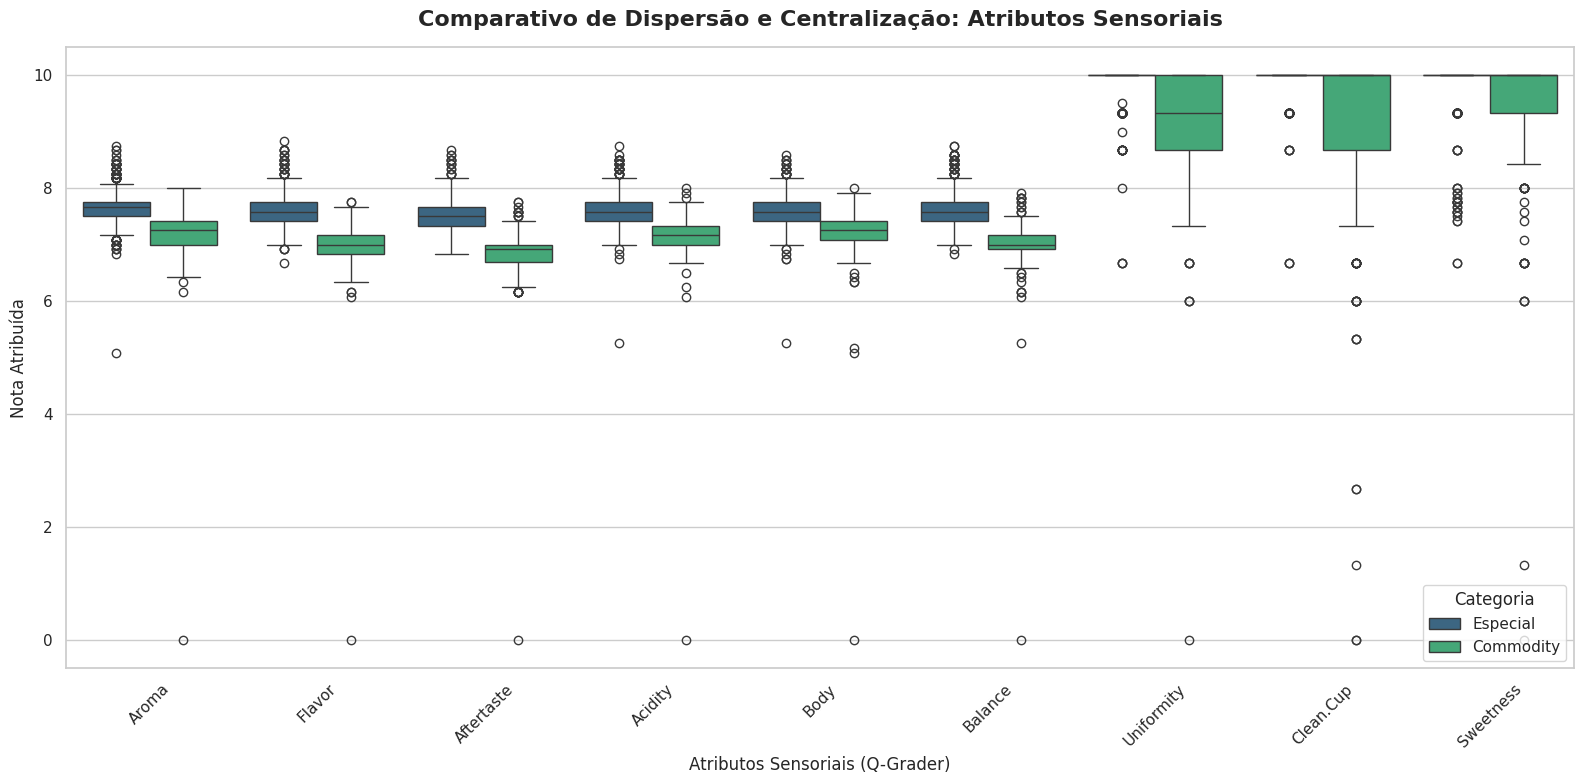


 TABELA: ESPECIAL vs COMMODITY


Média            Mediana          Desvio_Padrão         
Classe     Commodity Especial Commodity Especial     Commodity Especial
Atributo                                                               
Acidity         7.15     7.60      7.17     7.58          0.60     0.29
Aftertaste      6.86     7.49      6.92     7.50          0.60     0.28
Aroma           7.18     7.63      7.25     7.67          0.61     0.28
Balance         7.01     7.60      7.00     7.58          0.62     0.29
Body            7.18     7.57      7.25     7.58          0.63     0.27
Clean.Cup       9.01     9.97     10.00    10.00          1.77     0.21
Flavor          6.98     7.61      7.00     7.58          0.60     0.27
Sweetness       9.46     9.92     10.00    10.00          1.31     0.37
Uniformity      9.22     9.93      9.33    10.00          1.15     0.27

In [62]:
## Objetivo: Comparar visualmente e matematicamente a distribuição de notas entre Cafés Especiais e Commodities.
from IPython.display import display

atributos_sensoriais = ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness']

df_melted = df_clean.melt(id_vars=['Is_Specialty'], value_vars=atributos_sensoriais,
                          var_name='Atributo', value_name='Nota')

df_melted['Classe'] = df_melted['Is_Specialty'].map({0: 'Commodity', 1: 'Especial'})

plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df_melted, x='Atributo', y='Nota', hue='Classe', palette='viridis')

plt.title('Comparativo de Dispersão e Centralização: Atributos Sensoriais', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Atributos Sensoriais (Q-Grader)', fontsize=12)
plt.ylabel('Nota Atribuída', fontsize=12)
plt.legend(title='Categoria', loc='lower right')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Calculamos os indicadores exatos que formam o desenho do Boxplot
resumo_estatistico = df_melted.groupby(['Atributo', 'Classe'])['Nota'].agg(
    Média='mean',
    Mediana='median', # A linha central da caixa
    Desvio_Padrão='std' # O tamanho da dispersão (tamanho da caixa/hastes)
).reset_index()

# Reorganizamos a tabela (Pivot) para comparar as classes lado a lado
tabela_pivot = resumo_estatistico.pivot(
    index='Atributo',
    columns='Classe',
    values=['Média', 'Mediana', 'Desvio_Padrão']
)

# Arredondamos para 2 casas decimais para ficar com visual limpo
tabela_pivot = tabela_pivot.round(2)

print("\n" + "="*70)
print(" TABELA: ESPECIAL vs COMMODITY")
print("="*70)
display(tabela_pivot)

### **Relatório Executivo: Otimização e Previsibilidade na Qualidade do Café**

Este relatório consolida um diagnóstico operacional e propõe um plano de ação unindo Controle Estatístico de Processo (CEP) e *Machine Learning* para garantir a padronização em escala global.

### **1. Diagnóstico Operacional**

* **A Qualidade é Mensurável:** Cafés Especiais distinguem-se não apenas por notas superiores, mas pela baixa variabilidade de seus atributos. A excelência decorre da repetibilidade do processo pós-colheita.
* **O Gargalo é a Secagem:** A principal causa de inconsistência na padronização da torra é a variação na umidade dos grãos entregues (fora da faixa exigida de 10% a 12%). A raiz do problema concentra-se nas práticas de secagem dos fornecedores além de fatores agronômicos.
* **Rastreabilidade de Defeitos:** O monitoramento estatístico isolou 16 lotes críticos. Tais desvios não são aleatórios; configuram falhas operacionais específicas (colheita, processamento ou transporte) que podem ser auditadas e corrigidas.
* **Eficácia Preditiva:** O modelo de *Machine Learning* validado comprova ser possível prever a qualidade do lote (Especial vs. Commodity) no ato do recebimento, utilizando apenas dados físicos e de rastreabilidade.

### **2. Plano de Ação Estratégico**

As iniciativas abaixo visam otimizar recursos operacionais e mitigar riscos de fornecimento, ordenadas por prioridade:

1. **Triagem Preditiva no Recebimento (Imediato):**
Implantar o algoritmo de classificação na porta de entrada da indústria. O sistema avaliará os dados físicos e emitirá um *score* de risco de qualidade. Lotes fora do padrão serão bloqueados automaticamente para inspeção prioritária ou renegociação comercial, dispensando a avaliação laboratorial preliminar.
2. **Auditoria em Fornecedores Críticos (Curto Prazo):**
Executar rastreamento imediato das origens dos 16 lotes anômalos identificados no estudo. O objetivo é aplicar ações corretivas, acionar cláusulas de penalidade ou descredenciar fornecedores ineficientes.
3. **Programa de Padronização de Secagem (Médio Prazo):**
Instituir métricas de umidade (10% a 12%) como Acordo de Nível de Serviço (SLA) contratual, atrelado à precificação. Implementar visitas técnicas para auditar e capacitar os fornecedores nos processos de secagem.
4. **Mapeamento Sensorial por Origem (Longo Prazo):**
Expandir o Controle Estatístico para os 10 maiores países fornecedores da companhia. A meta é criar perfis de qualidade por *terroir*, utilizando os dados para curadoria de portfólio e não apenas para controle de falhas.
5. **Ciclo de Atualização do Algoritmo (Contínuo):**
Garantir o retreinamento semestral do modelo de *Machine Learning* com novos dados de safra. Isso previne a perda de precisão do sistema frente a mudanças climáticas ou novos métodos de processamento.

### **3. Impacto nos Negócios**

A integração entre prevenção (monitoramento estatístico de falhas) e antecipação (predição de qualidade via Inteligência Artificial) estabelece uma barreira de controle robusta. Para uma operação global, esse modelo garante:

* **Redução de Custos:** Otimização do tempo de processamento laboratorial (Q-Graders) e inspeção direcionada.
* **Mitigação de Riscos:** Bloqueio imediato de lotes que comprometem a qualidade final.
* **Proteção à Marca:** Garantia de consistência na experiência do consumidor final, blindando o principal ativo da companhia.